<a href="https://colab.research.google.com/github/wtryab-re/whats-your-eda/blob/main/Penguins_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install and Imports

In [170]:
!pip install -q seaborn matplotlib pandas numpy
!kaggle datasets download satyajeetrai/palmer-penguins-dataset-for-eda

Dataset URL: https://www.kaggle.com/datasets/satyajeetrai/palmer-penguins-dataset-for-eda
License(s): MIT
palmer-penguins-dataset-for-eda.zip: Skipping, found more recently modified local copy (use --force to force download)


In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [172]:
pd.set_option('display.max_columns', None)
sns.set_style("darkgrid")
pd.set_option("display.float_format", "{:.2f}".format)
np.random.seed(42)

##Dataset Unzip

In [173]:
unzip_file = zipfile.ZipFile("/content/palmer-penguins-dataset-for-eda.zip", "r")
x = unzip_file.extractall()
unzip_file.close()

In [174]:
df = pd.read_csv("penguins.csv")
df.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.10,18.70,181.00,3750.00,male,2007
1,1,Adelie,Torgersen,39.50,17.40,186.00,3800.00,female,2007
2,2,Adelie,Torgersen,40.30,18.00,195.00,3250.00,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.70,19.30,193.00,3450.00,female,2007


In [175]:
#Target value is species

#Data Quality Checks

Data Quality Checks:

0. Overview
1. Missing values summary
2. Duplicates
3. Data Type validation
4. Constant and quasi constant columns
5. ID like columns
6. String inconsistencies
7. High null columns
8. High zero columns

##0. Overview

In [176]:
df.shape

(344, 9)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [178]:
df.columns

Index(['id', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [179]:
df.describe()

,id,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.00,342.00,342.00,342.00,342.00,344.00
mean,171.50,43.92,17.15,200.92,4201.75,2008.03
std,99.45,5.46,1.97,14.06,801.95,0.82
min,0.00,32.10,13.10,172.00,2700.00,2007.00
25%,85.75,39.23,15.60,190.00,3550.00,2007.00
50%,171.50,44.45,17.30,197.00,4050.00,2008.00
75%,257.25,48.50,18.70,213.00,4750.00,2009.00
max,343.00,59.60,21.50,231.00,6300.00,2009.00


In [180]:
df.dtypes

,0
id,int64
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


In [181]:
df.nunique()

,0
id,344
species,3
island,3
bill_length_mm,164
bill_depth_mm,80
flipper_length_mm,55
body_mass_g,94
sex,2
year,3


In [182]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "year"]
cat_cols = ["species", "island", "sex"]

##1. Missing Values Check

In [183]:
df.isna().sum().sort_values(ascending=False)

,0
sex,11
body_mass_g,2
bill_depth_mm,2
flipper_length_mm,2
bill_length_mm,2
id,0
island,0
species,0
year,0


In [184]:
missing_count = df.isna().sum().sort_values(ascending=False).to_list()
missing_percentage = (df.isna().sum() / len(df)*100).sort_values(ascending=False).to_list()
missing_values = pd.DataFrame({"missing_count": missing_count, "missing_percentage": missing_percentage}, index=df.isna().sum().sort_values(ascending=False).index)
missing_values

,missing_count,missing_percentage
sex,11,3.20
body_mass_g,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
bill_length_mm,2,0.58
id,0,0.00
island,0,0.00
species,0,0.00
year,0,0.00


Have to drop or impute missing values

##2. Duplicates

In [185]:
df.duplicated().sum()

np.int64(0)

In [186]:
df[df.duplicated(keep=False)]

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year


##3. Data Type Validation

In [187]:
df.dtypes

,0
id,int64
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


##4. Constant or Quasi Constant Cols

In [188]:
const_cols = []
for col in df.columns:
  if df[col].nunique() == 1:
    const_cols.append(col)

print(const_cols)

[]


No constant columns

In [189]:
quasi_const_cols = []
#quasi const cols are cols that have mostly constant values, they arent useful for the models so we need to see if thats the case here.
#We can do an 90% percent of total rows as a benchmark
for col in df.columns:
  top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
  if top_freq > 0.9:
    quasi_const_cols.append(col)

print(quasi_const_cols)

[]


In [190]:
#No almost constant columns either.

##5. ID-LIKE COLUMNS

In [191]:
#Checks if any columns are like id, no real correlation.

In [192]:
n_rows = len(df)
id_like_cols = []
for col in df.columns:
  if df[col].nunique() > 0.95*n_rows:
    id_like_cols.append(col)

print(id_like_cols)

['id']


## 6. String Inconsistencies

In [193]:
text_cols = df.select_dtypes(include=(np.object_)).columns
text_cols

Index(['species', 'island', 'sex'], dtype='object')

In [194]:
for col in text_cols:
  df[col]= df[col].str.lower()
  df[col]= df[col].str.strip()
  df[col]= df[col].replace("nan", np.nan)
df[text_cols].head(2)

,species,island,sex
0,adelie,torgersen,male
1,adelie,torgersen,female


In [195]:
for col in text_cols:
  print(col, df[col].unique())

species ['adelie' 'gentoo' 'chinstrap']
island ['torgersen' 'biscoe' 'dream']
sex ['male' 'female' nan]


## 7. High Null Columns -- The same as Missing Columns

In [196]:
from pandas.core.dtypes import missing
##40% is a high null col
high_null_value = 40
missing_count = df.isna().sum().sort_values(ascending=False).to_list()
missing_percentage = df.isna().sum() / len(df)*100
missing_values = pd.DataFrame({"missing_count": missing_count, "missing_percentage": missing_percentage}, index=df.isna().sum().sort_values(ascending=False).index)
missing_values[missing_values["missing_percentage"]>high_null_value]

,missing_count,missing_percentage


## 8. High Zero Columns

In [197]:
##40% is a high zero col

high_zero_column = 40
numeric_cols = df.select_dtypes(include=np.number).columns
high_zero_threshold = 40
zero_values = (df[numeric_cols]==0).mean()*100
zero_values.sort_values(ascending=False,inplace=True)
zero_values[zero_values>high_zero_threshold]

,0


In [198]:
##No high zero columns or null columns

#Univariate Analysis

In [199]:
df.sample()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
194,194,gentoo,biscoe,45.30,13.70,210.00,4300.00,female,2008


In [200]:
df.shape

(344, 9)

In [201]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_cols = ["species", "island", "sex", "year"]

##Numerical Cols Univariate Analysis

Checks of Central Measures

Checks of Dispersion

Checks of Skewness

Checks of Kurtosis

Boxplots, Histograms

Categorical - frequency, countplots

###Central Measures, Dispersion, Skewness, Kurtosis

In [202]:
measures = df[num_cols].describe().T
measures["range"]= df[num_cols].max()-df[num_cols].min()
measures["skew"] = df[num_cols].skew()
measures["kurtosis"] = df[num_cols].kurtosis()
measures["variance"]= df[num_cols].var()
measures

,count,mean,std,min,25%,50%,75%,max,range,skew,kurtosis,variance
bill_length_mm,342.00,43.92,5.46,32.10,39.23,44.45,48.50,59.60,27.50,0.05,-0.88,29.81
bill_depth_mm,342.00,17.15,1.97,13.10,15.60,17.30,18.70,21.50,8.40,-0.14,-0.91,3.90
flipper_length_mm,342.00,200.92,14.06,172.00,190.00,197.00,213.00,231.00,59.00,0.35,-0.98,197.73
body_mass_g,342.00,4201.75,801.95,2700.00,3550.00,4050.00,4750.00,6300.00,3600.00,0.47,-0.72,643131.08


###Histograms

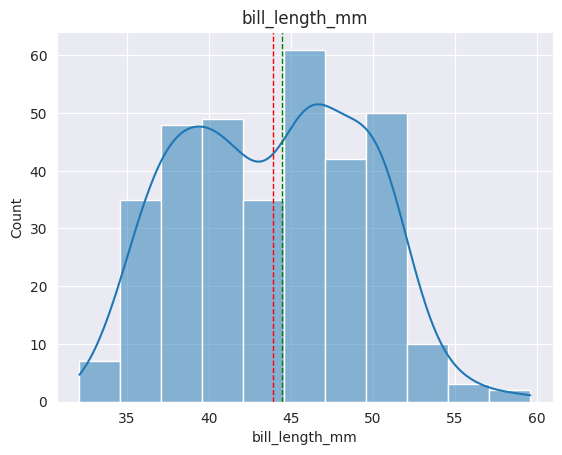

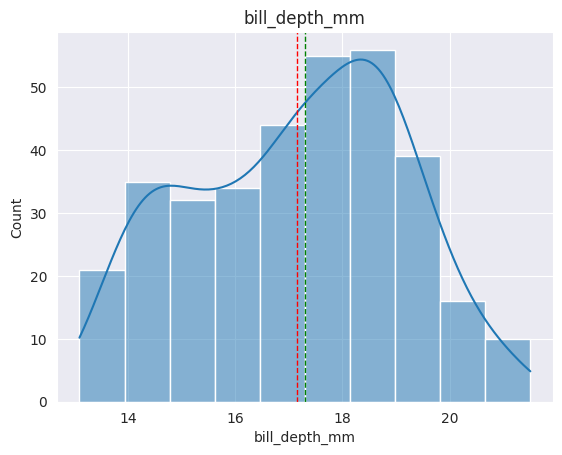

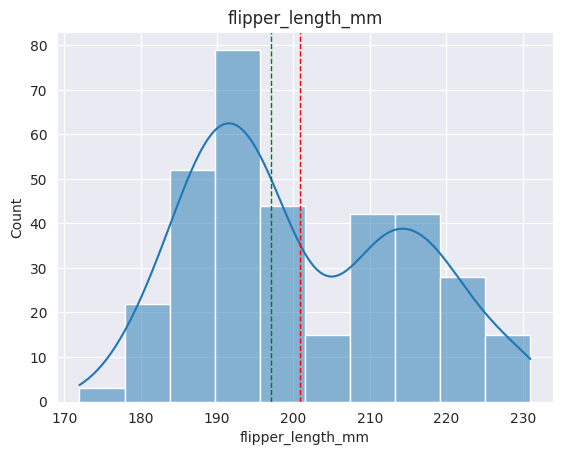

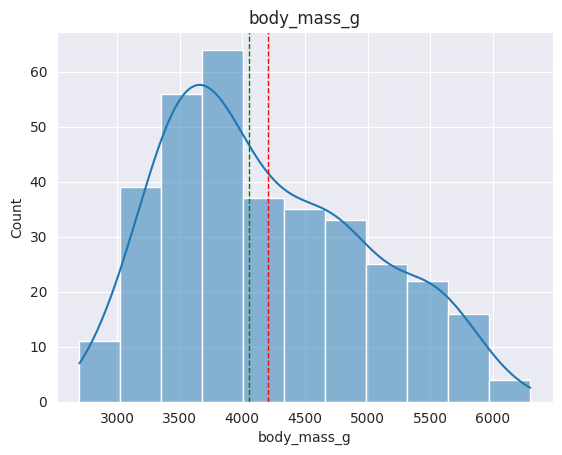

In [203]:
for col in num_cols:
  sns.histplot(df[col],kde=True)
  plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1)
  plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=1)
  plt.title(col)
  plt.show()
  print()

###Boxplots

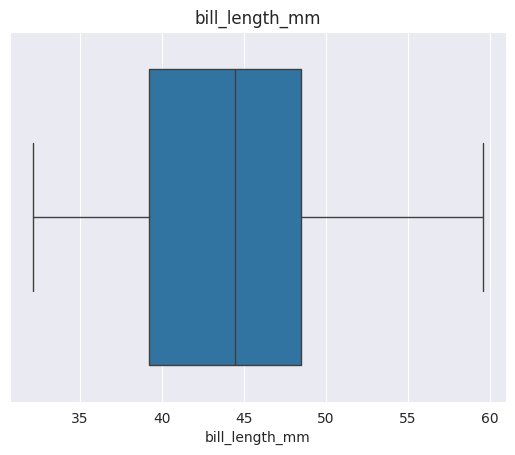

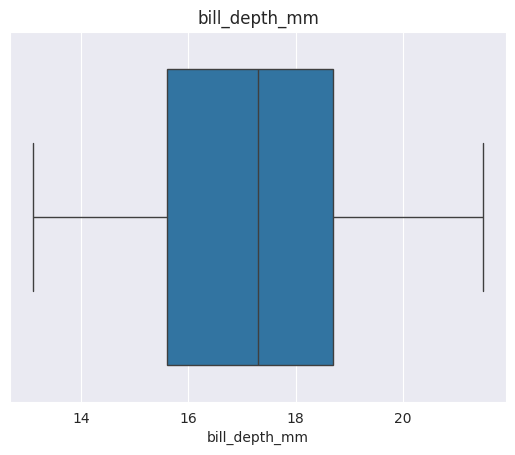

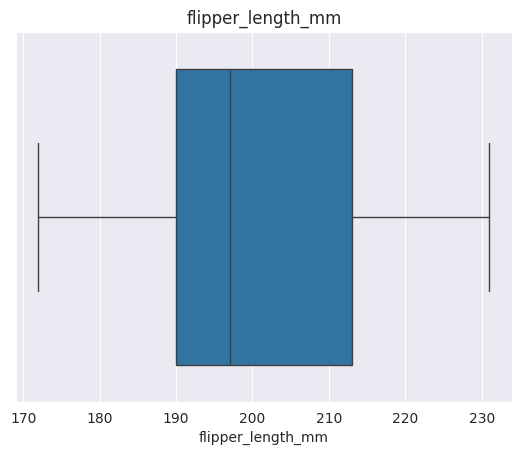

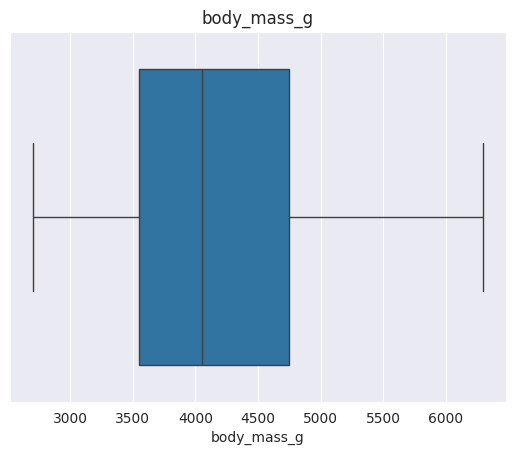

In [204]:
for col in num_cols:
  sns.boxplot(df[col], orient="h")
  plt.title(col)
  plt.show()
  print()

Key Findings of Numerical Univariate Analysis:

Almost equal sets of data in terms of year,

body_mass_g is positive skewed

bill_depth_mm is slightly right skewed

bill_length_mm is right skewed

flipper_length_mm is right skewed

no data is uniform or normal distribution

No outliers found

##Univariate Analysis of Categorical Features

###Countplots

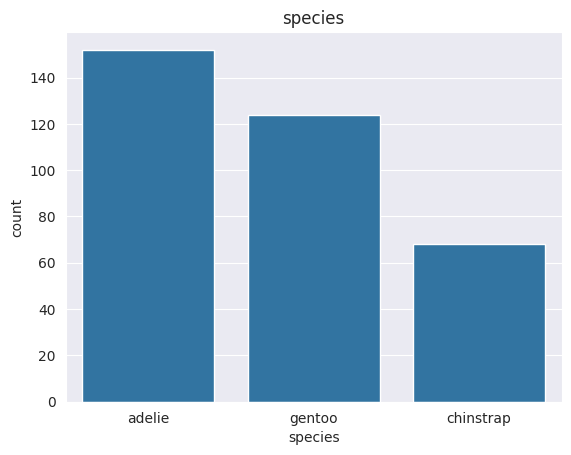

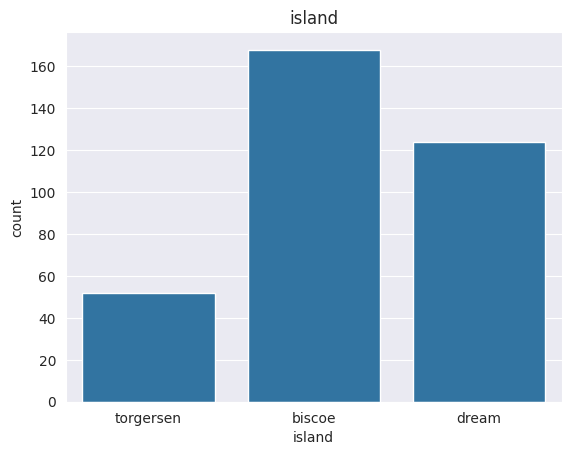

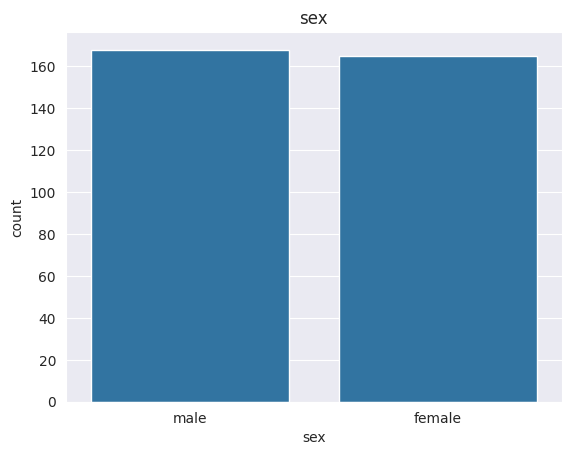

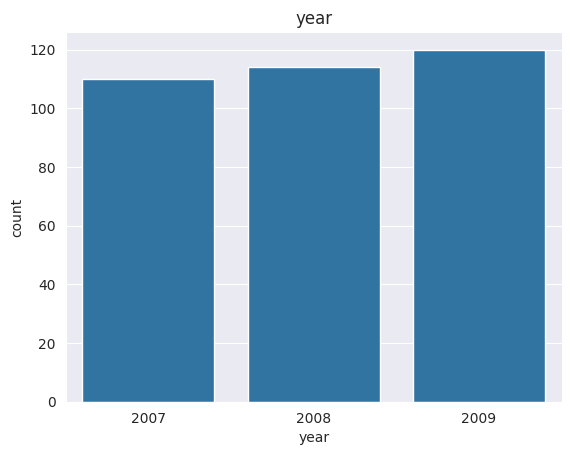

In [205]:
for col in cat_cols:
  sns.countplot(x = df[col])
  plt.title(col)
  plt.show()
  print()

###Frequency Counts/Proportions:

In [210]:
for cols in cat_cols:
  print(df[cols].value_counts(normalize=True))
  print()

species
adelie      0.44
gentoo      0.36
chinstrap   0.20
Name: proportion, dtype: float64

island
biscoe      0.49
dream       0.36
torgersen   0.15
Name: proportion, dtype: float64

sex
male     0.50
female   0.50
Name: proportion, dtype: float64

year
2009   0.35
2008   0.33
2007   0.32
Name: proportion, dtype: float64



Key findings of Categorical Univariate Analysis:

Species is imbalanced

Island is imbalanced

Year is almost balanced

sex is almost balanced

#Bivariate Analysis

In [206]:
num_to_num_pairs = []
for i in range(len(num_cols)):
  for j in range(i+1, len(num_cols)):
    num_to_num_pairs.append((num_cols[i], num_cols[j]))
num_to_num_pairs

[('bill_length_mm', 'bill_depth_mm'),
 ('bill_length_mm', 'flipper_length_mm'),
 ('bill_length_mm', 'body_mass_g'),
 ('bill_depth_mm', 'flipper_length_mm'),
 ('bill_depth_mm', 'body_mass_g'),
 ('flipper_length_mm', 'body_mass_g')]

In [207]:
cat_to_cat_pairs = []
for i in range(len(cat_cols)):
  for j in range(i+1, len(cat_cols)):
    cat_to_cat_pairs.append((cat_cols[i], cat_cols[j]))
cat_to_cat_pairs

[('species', 'island'),
 ('species', 'sex'),
 ('species', 'year'),
 ('island', 'sex'),
 ('island', 'year'),
 ('sex', 'year')]

In [208]:
num_to_cat_pairs = []
for i in range(len(num_cols)):
  for j in range(len(cat_cols)):
    num_to_cat_pairs.append((num_cols[i], cat_cols[j]))
num_to_cat_pairs

[('bill_length_mm', 'species'),
 ('bill_length_mm', 'island'),
 ('bill_length_mm', 'sex'),
 ('bill_length_mm', 'year'),
 ('bill_depth_mm', 'species'),
 ('bill_depth_mm', 'island'),
 ('bill_depth_mm', 'sex'),
 ('bill_depth_mm', 'year'),
 ('flipper_length_mm', 'species'),
 ('flipper_length_mm', 'island'),
 ('flipper_length_mm', 'sex'),
 ('flipper_length_mm', 'year'),
 ('body_mass_g', 'species'),
 ('body_mass_g', 'island'),
 ('body_mass_g', 'sex'),
 ('body_mass_g', 'year')]

##Numerical to Numerical Analysis

Scatterplots, Correlation Matrix, Heatmap, Pairplot

###Pairplot

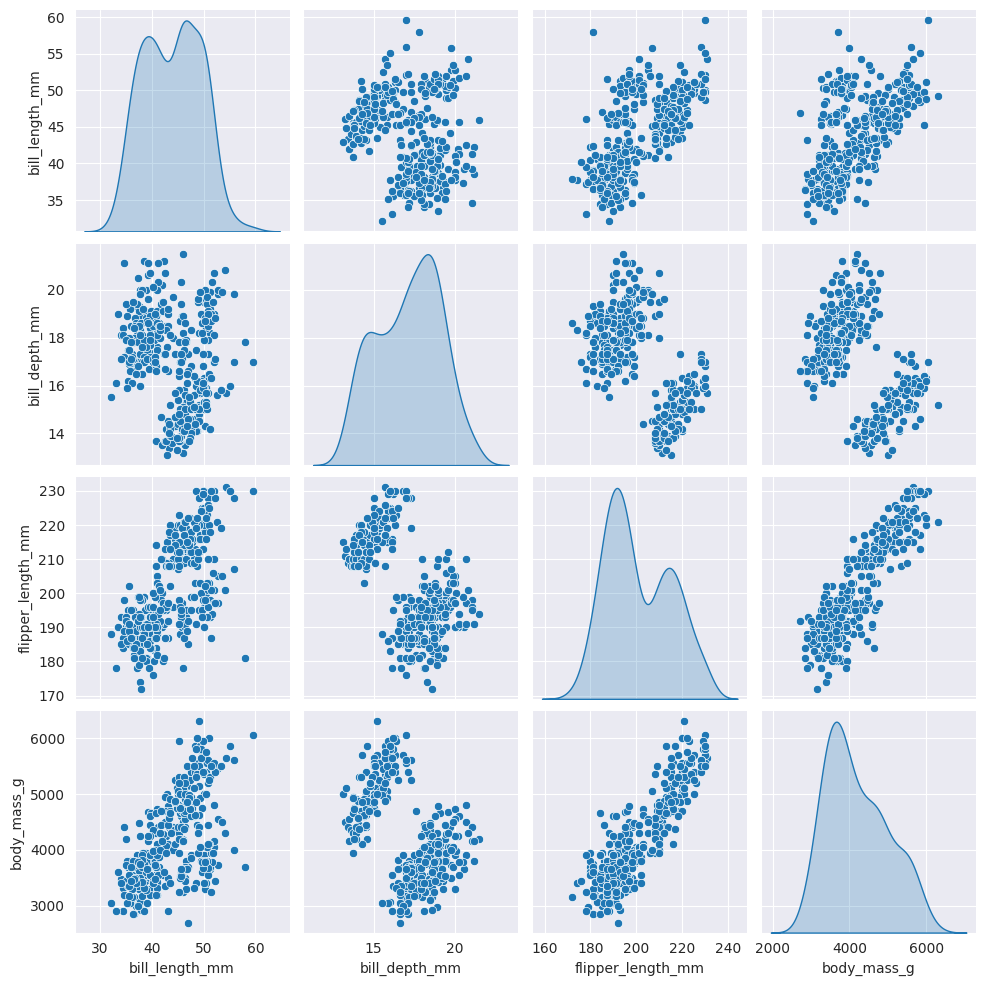

In [216]:
sns.pairplot(df[num_cols], diag_kind="kde")
plt.show()

Key Findings:
1. Almost Linear Relation between body_mass w flipper length
2. Cluster relation between body mass and bill depth. unusual hmm, if bill is thicker shouldnt the mass be heavier
3. Cluster relation between flipper length : bill depth and bill length
4. Cluster relation bewteen bill length and bill depth

###Scatterplots

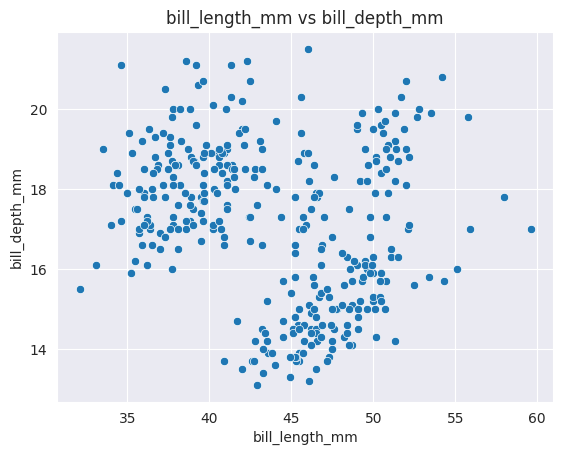

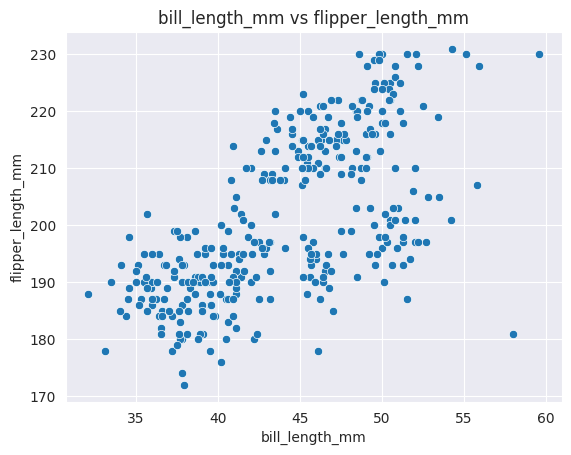

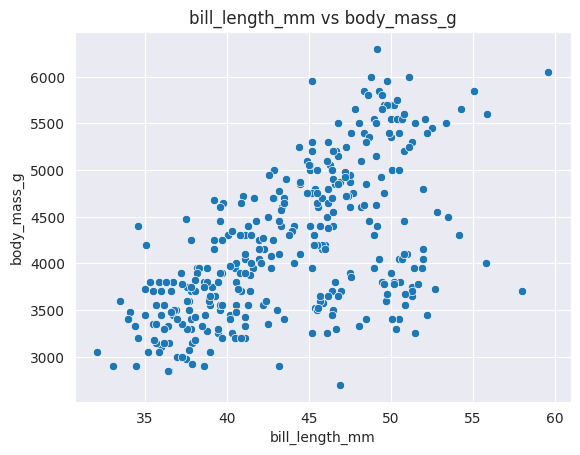

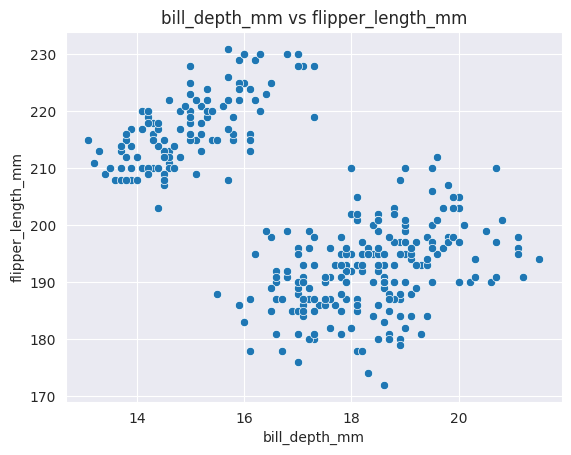

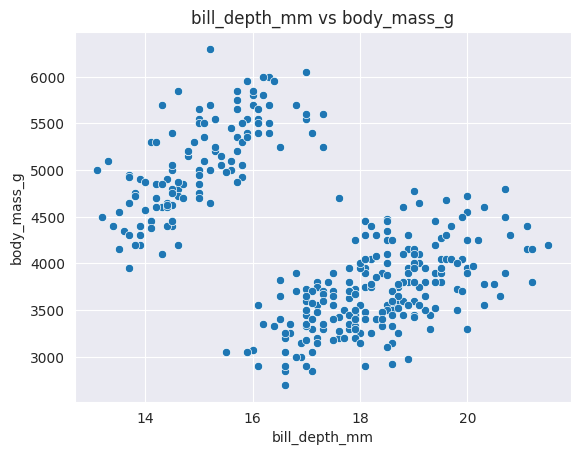

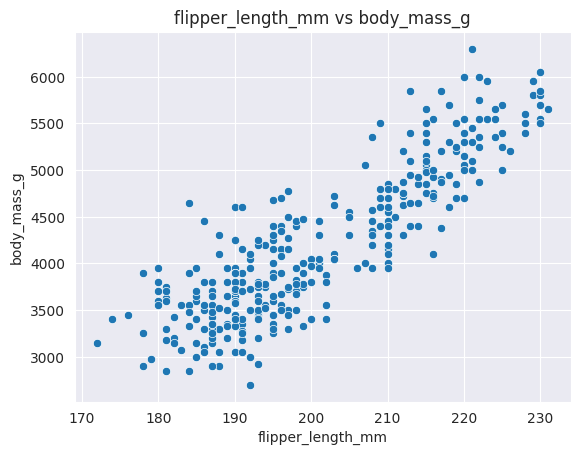

In [219]:
for col1,col2 in num_to_num_pairs:
  sns.scatterplot(x=col1, y=col2, data=df)
  plt.title(f"{col1} vs {col2}")
  plt.show()
  print()

###Correlation Matrix

In [221]:
df[num_cols].corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


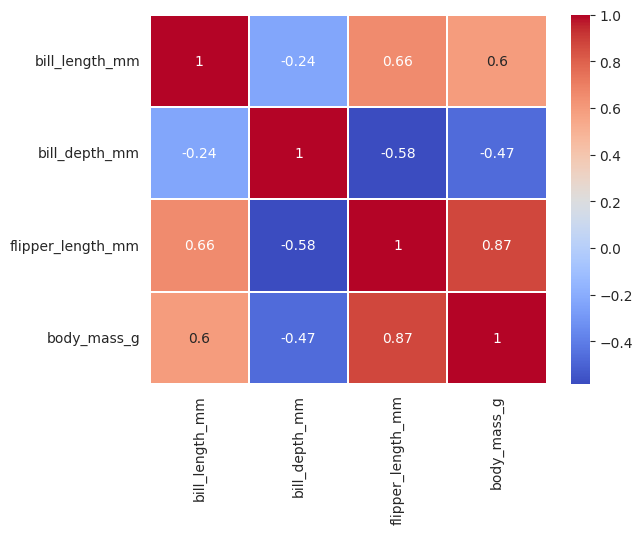

In [223]:
sns.heatmap(df[num_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.3)
plt.show()

###Pearson Correlation Coefficient

--if p is low <0.05 then it is confident that there is a relationship or else it is not.

--PCC measures correlation through a linear lens, it is possible that the correlation is not linear but some other type like quadratic.

In [226]:
!pip install -q scipy
from scipy.stats import pearsonr

In [236]:
for col1,col2 in num_to_num_pairs:
  r,p = pearsonr(df[col1].dropna(), df[col2].dropna())
  print(f"{col1} vs {col2}")
  print(f"r: {r}, p: {p}\n", "-"*50)

bill_length_mm vs bill_depth_mm
r: -0.23505287035553274, p: 1.1196621961373343e-05
 --------------------------------------------------
bill_length_mm vs flipper_length_mm
r: 0.656181340746428, p: 1.7439736176204212e-43
 --------------------------------------------------
bill_length_mm vs body_mass_g
r: 0.5951098244376299, p: 3.808282842018042e-34
 --------------------------------------------------
bill_depth_mm vs flipper_length_mm
r: -0.5838512164654126, p: 1.232733766814107e-32
 --------------------------------------------------
bill_depth_mm vs body_mass_g
r: -0.4719156211860666, p: 2.276941272540606e-20
 --------------------------------------------------
flipper_length_mm vs body_mass_g
r: 0.8712017673060112, p: 4.3706809630004724e-107
 --------------------------------------------------


##Numerical vs Categorical

###Boxplots

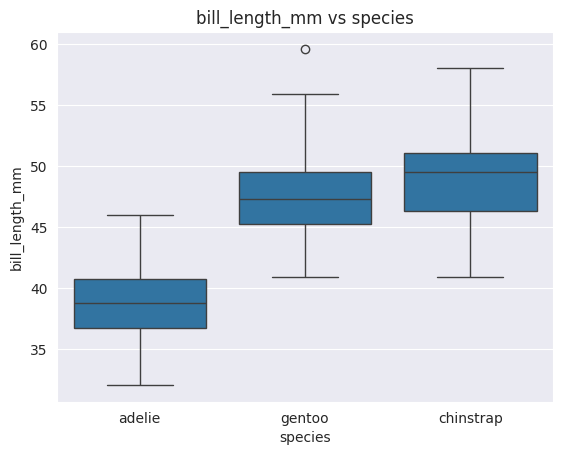

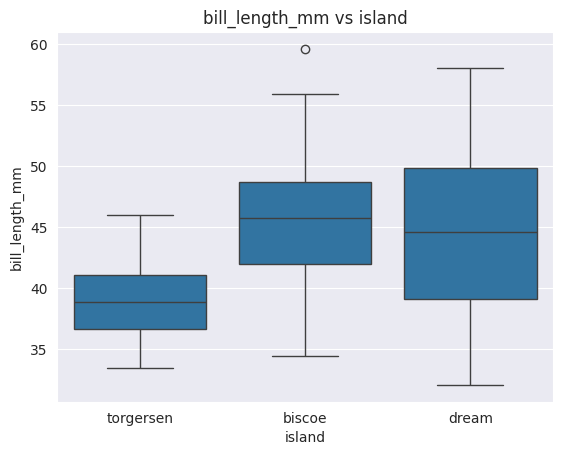

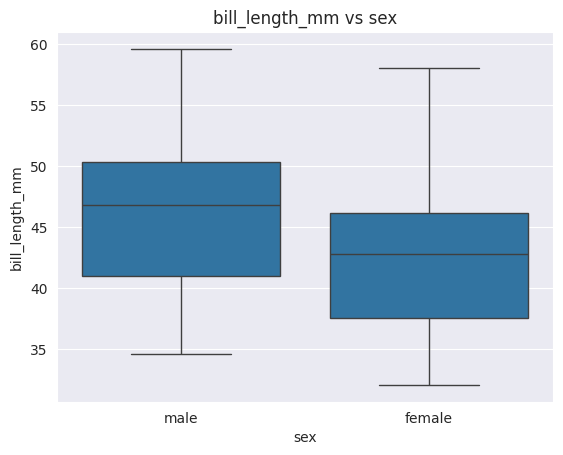

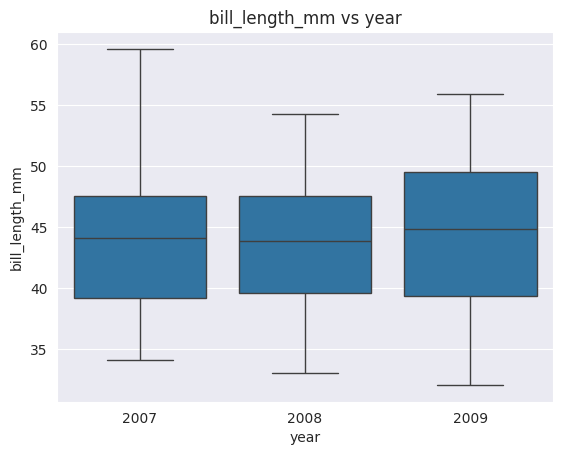

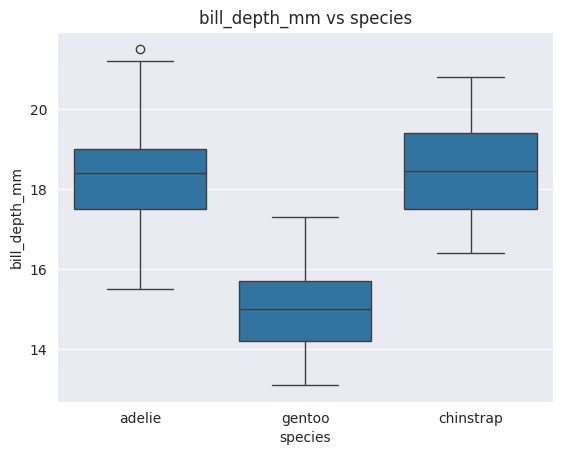

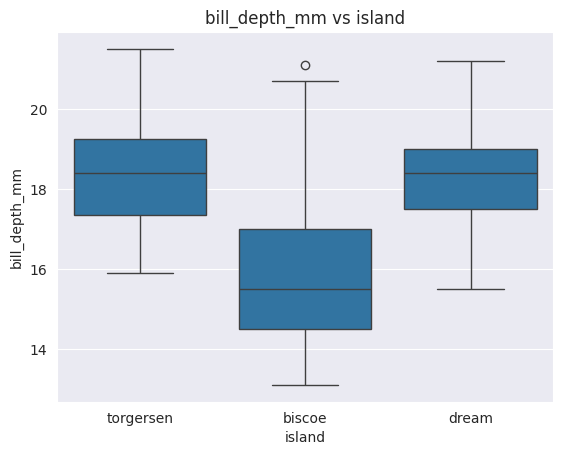

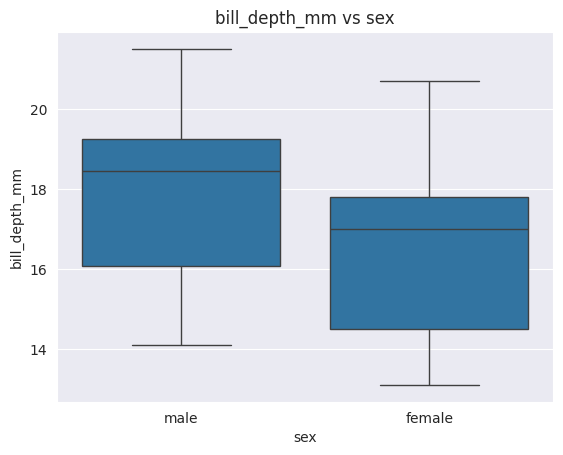

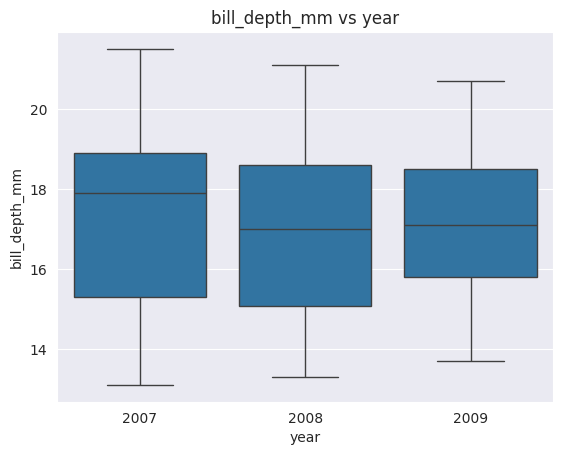

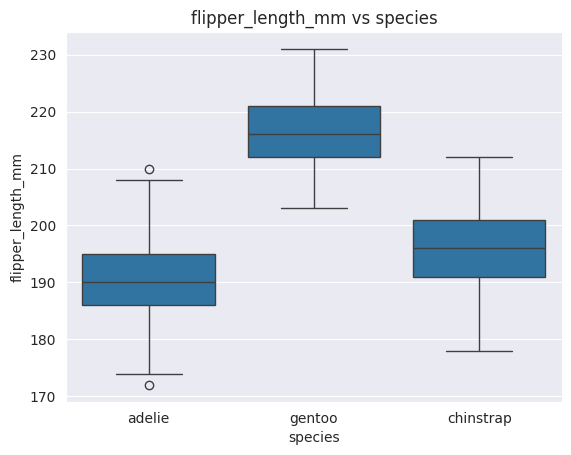

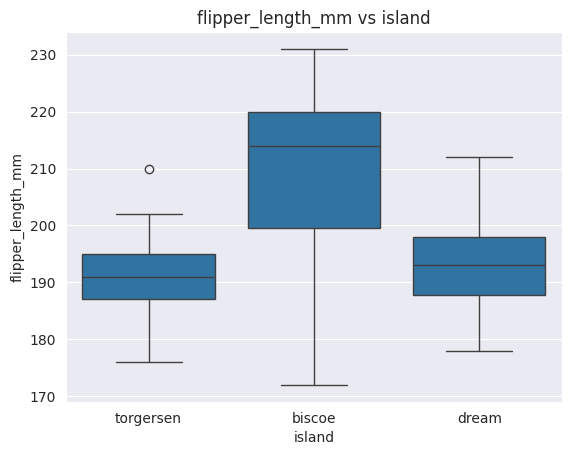

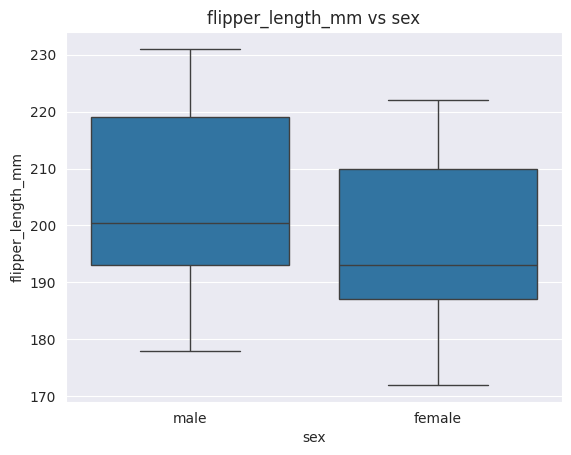

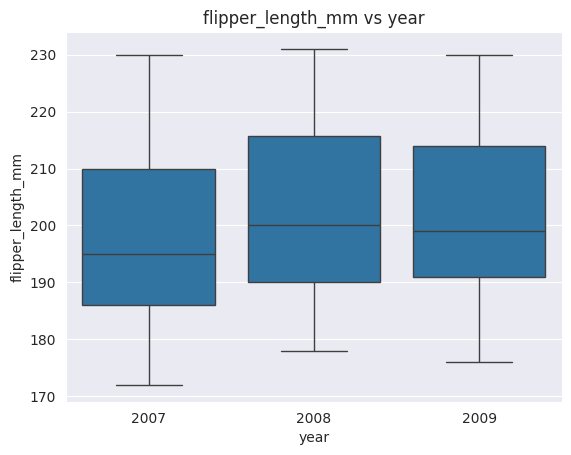

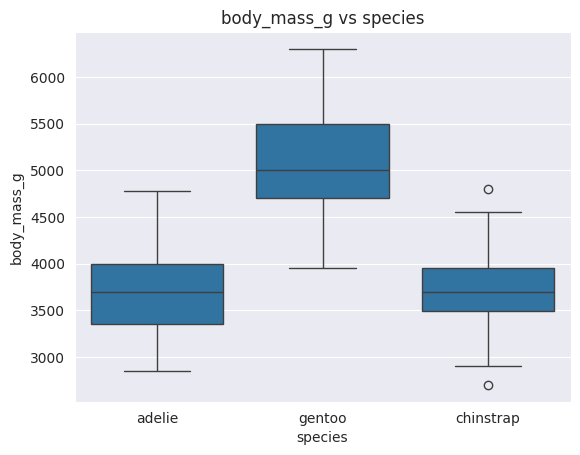

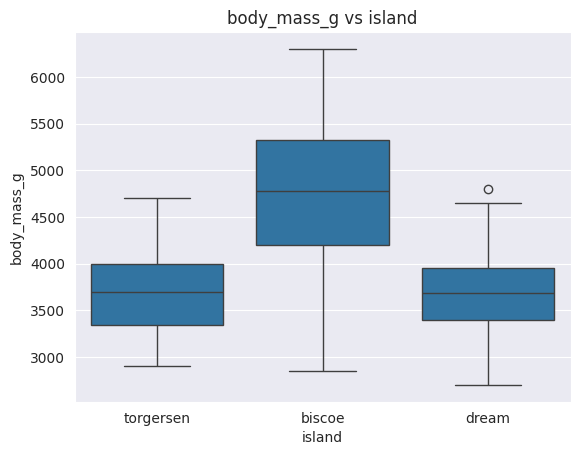

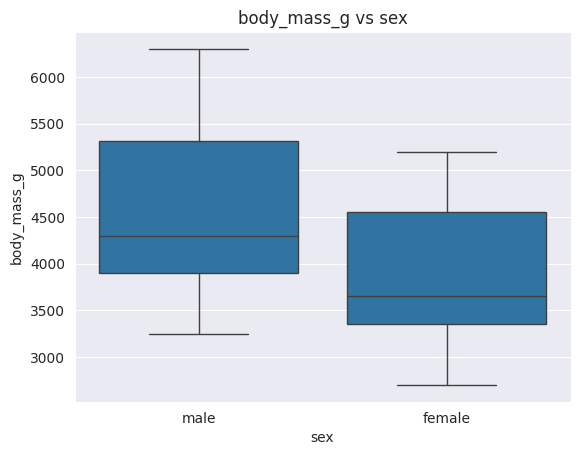

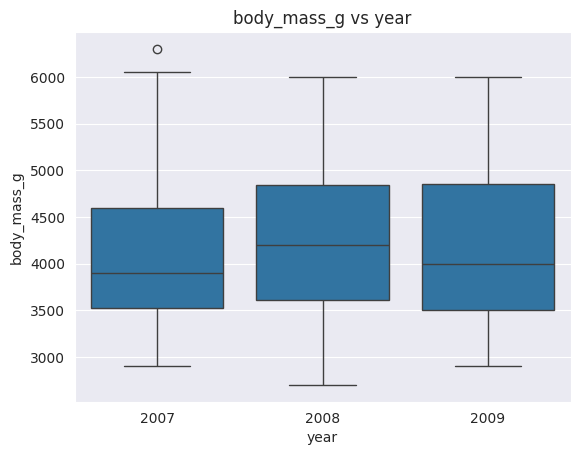

In [238]:
for col1,col2 in num_to_cat_pairs:
  sns.boxplot(x=col2, y=col1, data=df)
  plt.title(f"{col1} vs {col2}")
  plt.show()
  print()

###Grouped Stats

In [242]:
for col1,col2 in num_to_cat_pairs:
  print(df.groupby(col2)[col1].mean())
  print()

species
adelie      38.79
chinstrap   48.83
gentoo      47.50
Name: bill_length_mm, dtype: float64

island
biscoe      45.26
dream       44.17
torgersen   38.95
Name: bill_length_mm, dtype: float64

sex
female   42.10
male     45.85
Name: bill_length_mm, dtype: float64

year
2007   43.74
2008   43.54
2009   44.45
Name: bill_length_mm, dtype: float64

species
adelie      18.35
chinstrap   18.42
gentoo      14.98
Name: bill_depth_mm, dtype: float64

island
biscoe      15.87
dream       18.34
torgersen   18.43
Name: bill_depth_mm, dtype: float64

sex
female   16.43
male     17.89
Name: bill_depth_mm, dtype: float64

year
2007   17.43
2008   16.91
2009   17.13
Name: bill_depth_mm, dtype: float64

species
adelie      189.95
chinstrap   195.82
gentoo      217.19
Name: flipper_length_mm, dtype: float64

island
biscoe      209.71
dream       193.07
torgersen   191.20
Name: flipper_length_mm, dtype: float64

sex
female   197.36
male     204.51
Name: flipper_length_mm, dtype: float64

year
2007 

Key Findings:
1. On average all female birds have smaller masses, length and depth than male birds

##Categorical vs Categorical

###CrossTab

In [249]:
for col1,col2 in cat_to_cat_pairs:
  print(pd.crosstab(df[col1], df[col2], margins=True, margins_name="Total"))
  print()

island     biscoe  dream  torgersen  Total
species                                   
adelie         44     56         52    152
chinstrap       0     68          0     68
gentoo        124      0          0    124
Total         168    124         52    344

sex        female  male  Total
species                       
adelie         73    73    146
chinstrap      34    34     68
gentoo         58    61    119
Total         165   168    333

year       2007  2008  2009  Total
species                           
adelie       50    50    52    152
chinstrap    26    18    24     68
gentoo       34    46    44    124
Total       110   114   120    344

sex        female  male  Total
island                        
biscoe         80    83    163
dream          61    62    123
torgersen      24    23     47
Total         165   168    333

year       2007  2008  2009  Total
island                            
biscoe       44    64    60    168
dream        46    34    44    124
torgersen    20 

In [251]:
for col1,col2 in cat_to_cat_pairs:
  print(pd.crosstab(df[col1], df[col2], margins=True, margins_name="Total", normalize=True))
  print()

island     biscoe  dream  torgersen  Total
species                                   
adelie       0.13   0.16       0.15   0.44
chinstrap    0.00   0.20       0.00   0.20
gentoo       0.36   0.00       0.00   0.36
Total        0.49   0.36       0.15   1.00

sex        female  male  Total
species                       
adelie       0.22  0.22   0.44
chinstrap    0.10  0.10   0.20
gentoo       0.17  0.18   0.36
Total        0.50  0.50   1.00

year       2007  2008  2009  Total
species                           
adelie     0.15  0.15  0.15   0.44
chinstrap  0.08  0.05  0.07   0.20
gentoo     0.10  0.13  0.13   0.36
Total      0.32  0.33  0.35   1.00

sex        female  male  Total
island                        
biscoe       0.24  0.25   0.49
dream        0.18  0.19   0.37
torgersen    0.07  0.07   0.14
Total        0.50  0.50   1.00

year       2007  2008  2009  Total
island                            
biscoe     0.13  0.19  0.17   0.49
dream      0.13  0.10  0.13   0.36
torgersen  0.06 

###Countplots

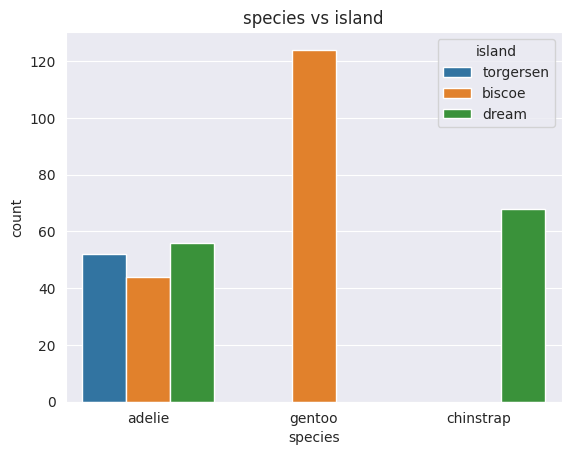

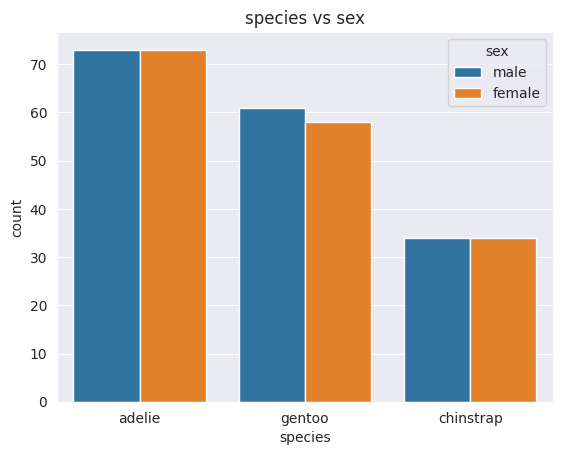

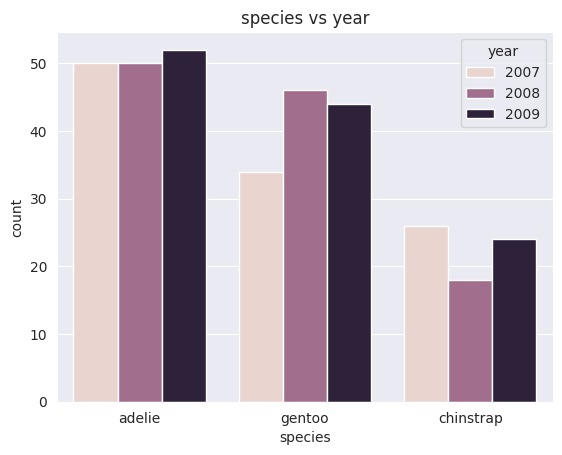

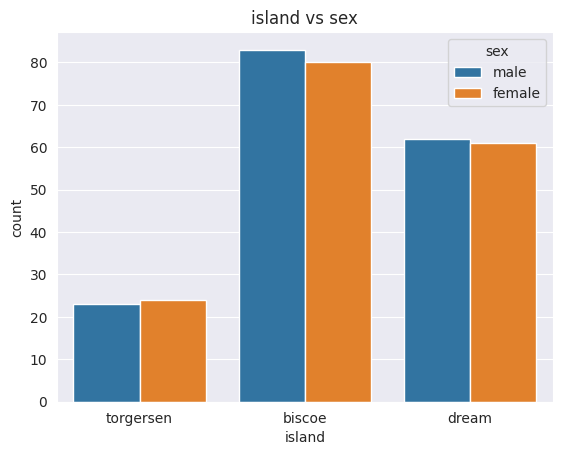

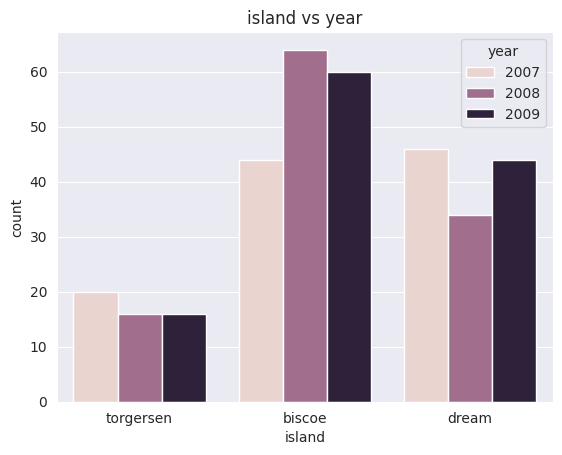

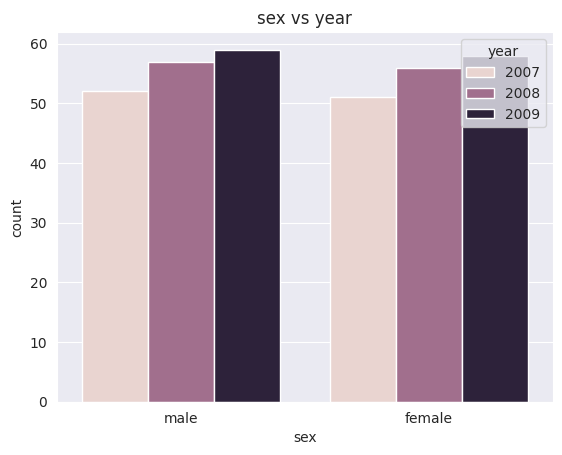

In [252]:
for col1,col2 in cat_to_cat_pairs:
  sns.countplot(x=col1, hue=col2, data=df)
  plt.title(f"{col1} vs {col2}")
  plt.show()
  print()

#Multivariate Analysis

pairplots w hues

scatterplots w hues

clustermap

##Pairplot

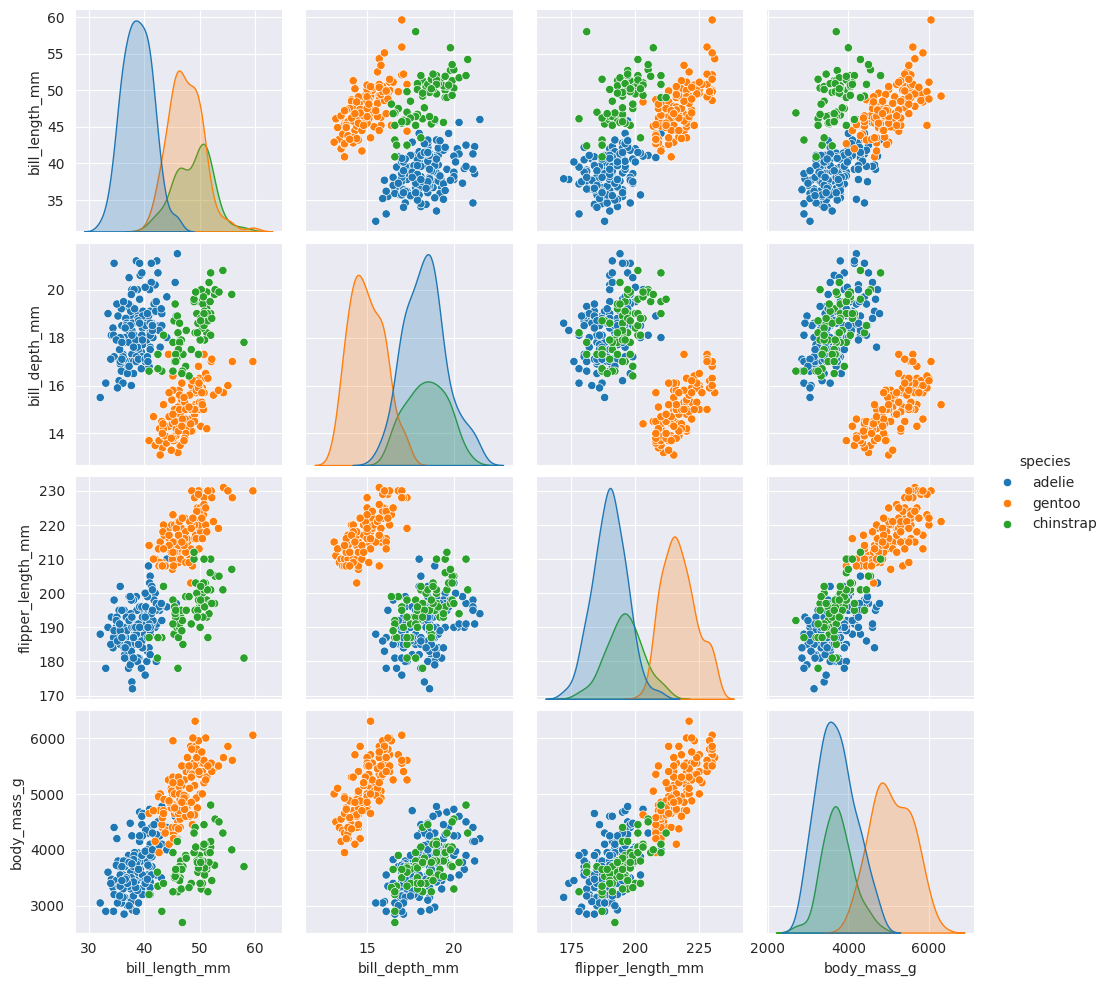

In [254]:
sns.pairplot(df[num_cols+["species"]], hue="species", diag_kind="kde")
plt.show()

##Clustermap

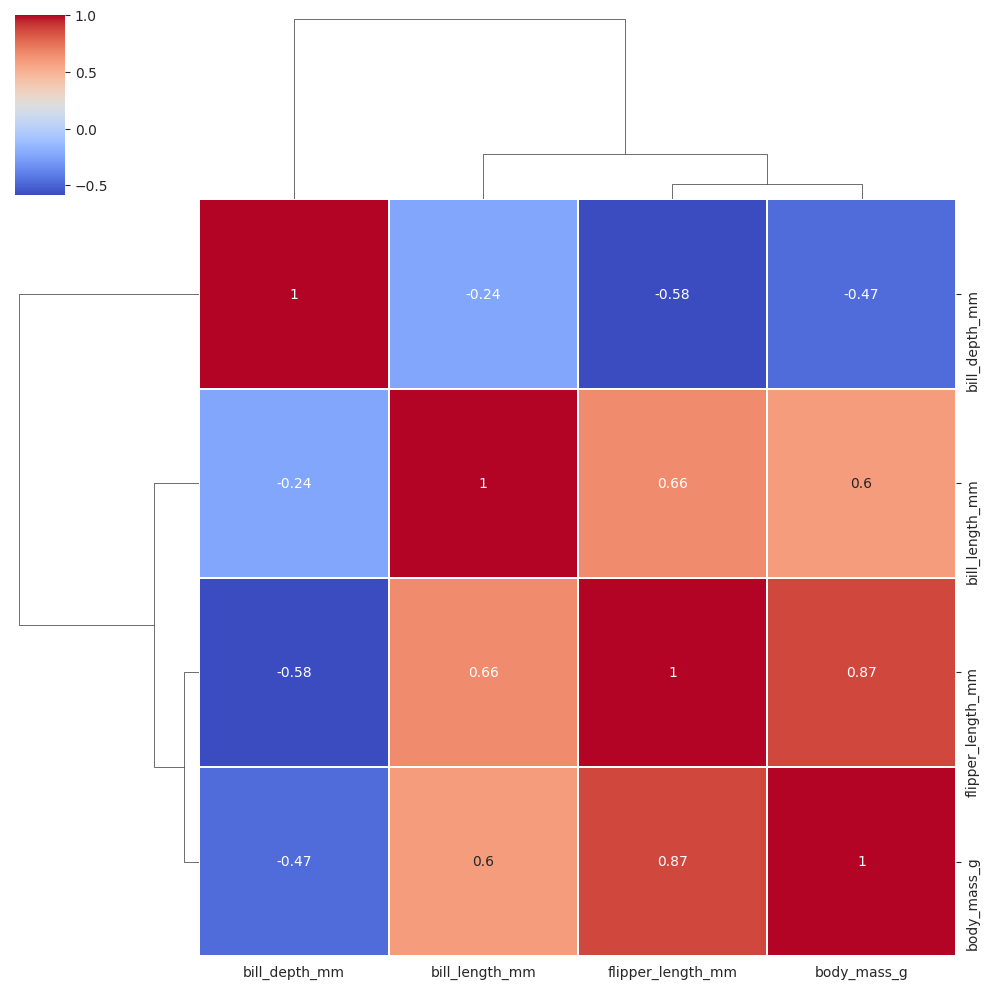

In [257]:
sns.clustermap(df[num_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.3)
plt.show()

##Interaction and Subgroup Patterns with Scatterplots and hues

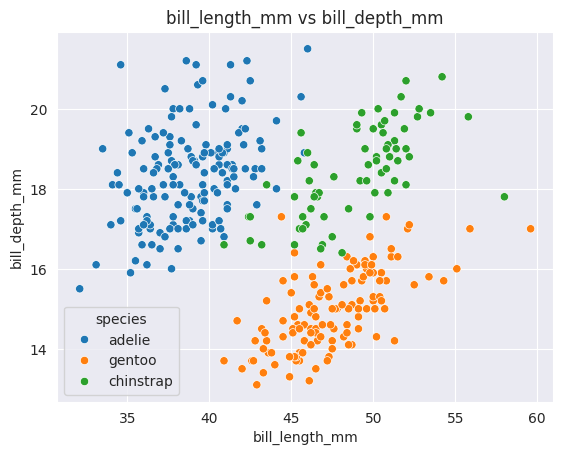

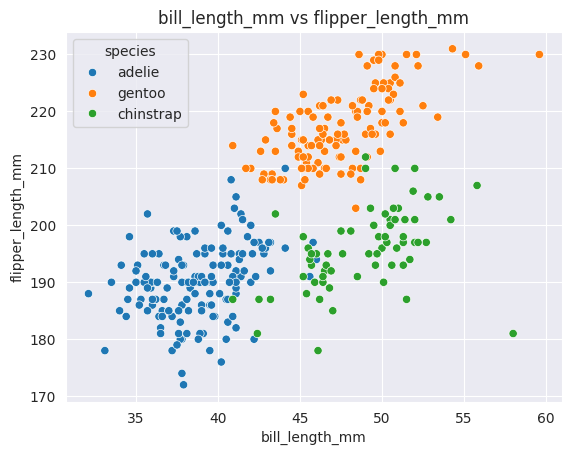

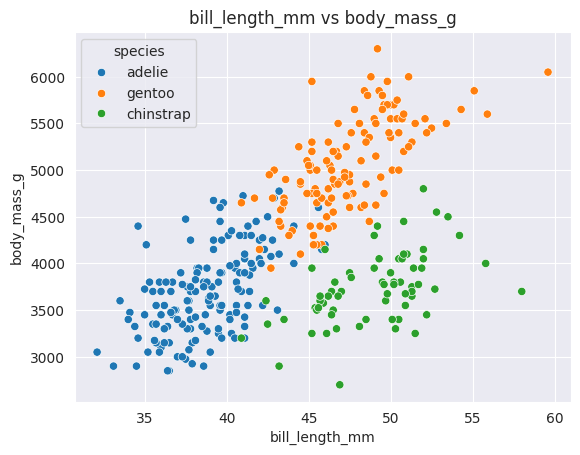

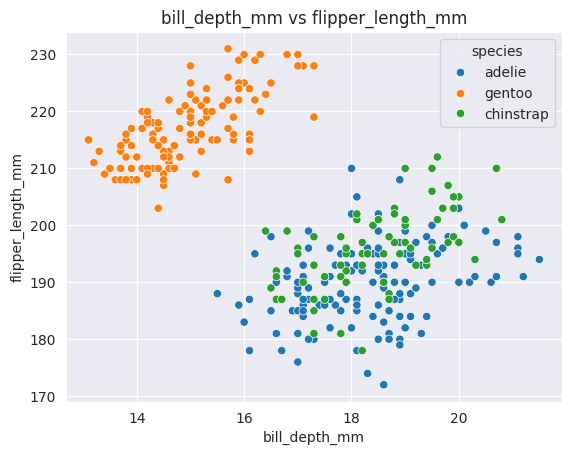

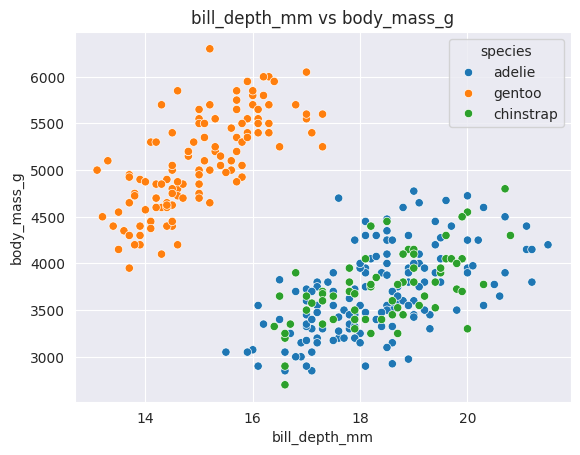

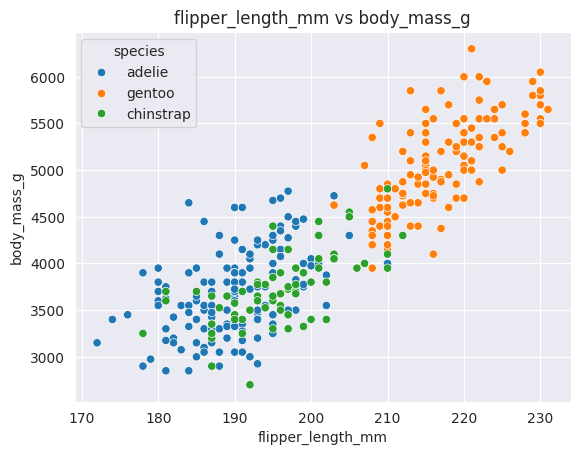

In [241]:
for col1,col2 in num_to_num_pairs:
  sns.scatterplot(x=col1, y=col2, hue="species", data=df)
  plt.title(f"{col1} vs {col2}")
  plt.show()
  print()

Key Findings:
1. All species have distinct ranges of mass, length, depth

#Outlier Detection

IQR AND Z-SCORE

##IQR Method

In [255]:
for col in num_cols:
  q3= df[col].quantile(0.75)
  q1= df[col].quantile(0.25)
  iqr = q3-q1
  lower_bound = q1-1.5*iqr
  upper_bound = q3+1.5*iqr
  outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  print("Col: ", col)
  print("Q1", q1)
  print("Q3", q3)
  print("IQR", iqr)
  print("Lower Bound", lower_bound)
  print("Upper Bound", upper_bound)
  print("Outliers ",outliers.value_counts().sum())
  print("Percentage Outliers=", outliers.value_counts().sum()/df.shape[0]*100,"\n")

Col:  bill_length_mm
Q1 39.225
Q3 48.5
IQR 9.274999999999999
Lower Bound 25.312500000000004
Upper Bound 62.412499999999994
Outliers  0
Percentage Outliers= 0.0 

Col:  bill_depth_mm
Q1 15.6
Q3 18.7
IQR 3.0999999999999996
Lower Bound 10.95
Upper Bound 23.349999999999998
Outliers  0
Percentage Outliers= 0.0 

Col:  flipper_length_mm
Q1 190.0
Q3 213.0
IQR 23.0
Lower Bound 155.5
Upper Bound 247.5
Outliers  0
Percentage Outliers= 0.0 

Col:  body_mass_g
Q1 3550.0
Q3 4750.0
IQR 1200.0
Lower Bound 1750.0
Upper Bound 6550.0
Outliers  0
Percentage Outliers= 0.0 



##Z-SCORE

Z-SCORE: -- assumes normal dist z= value-mean/std

z>3 is outlier

z<-3 is outlier

In [256]:
for col in num_cols:
  mean = df[col].mean()
  std = df[col].std()
  z_scores = (df[col]-mean)/std
  outliers = df[z_scores.abs()>3]
  print(col)
  print("Mean", mean)
  print("Std", std)
  print("Outliers", outliers.value_counts().sum())
  print("Percentage Outliers=", outliers.value_counts().sum()/df.shape[0]*100,"\n")

bill_length_mm
Mean 43.9219298245614
Std 5.4595837139265315
Outliers 0
Percentage Outliers= 0.0 

bill_depth_mm
Mean 17.151169590643274
Std 1.9747931568167818
Outliers 0
Percentage Outliers= 0.0 

flipper_length_mm
Mean 200.91520467836258
Std 14.061713679356888
Outliers 0
Percentage Outliers= 0.0 

body_mass_g
Mean 4201.754385964912
Std 801.9545356980958
Outliers 0
Percentage Outliers= 0.0 

